<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
اهدای خون
</font>
</h1>


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مقدمه و صورت مسئله
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
موسسه مرکزی اهدای خون تایوان، به منظور تحلیل داده‌های خود و پیش‌بینی نیاز به خون در این کشور، اقدام به واگذاری داده‌ی خود به دانشگاه ملی تایوان کرده است. دانشگاه ملی تایوان پس از بررسی‌های ابتدایی و اعمال تغییرات گسترده و استفاده از تکنینک‌های تحلیل رفتاری، داده‌ی ابتدایی را به شکلی که در ادامه معرفی خواهد شد، تبدیل کرده است.
    <br>
    حال ما می‌خواهیم پیش‌بینی کنیم آیا شهروندان تایوانی در تاریخ خاصی خون اهدا می‌کنند یا خیر!
</font>
</p>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
وارد کردن کتابخانه‌های مورد نیاز
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    ابتدا کتابخانه‌های مورد نیازتان را وارد کنید.
</font>
</p>

In [63]:
import pandas as pd 
import numpy as np
from sklearn.linear_model import LogisticRegression

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
معرفی مجموعه داده
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    در این سوال دو مجموعه داده در اختیار داریم. توضیحات مجموعه داده آموزش را در جدول زیر مشاهده می‌کنید: 
    <br>
    هر سطر از این مجموعه داده، اطلاعات یک شهروند را نشان می‌دهد.
</font>
</p>

<center>
<div dir=rtl style="line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    
|نام ویژگی|توضیحات|
|:------:|:---:|
|<code>Recency (months)</code>|تعداد ماهی که از آخرین زمان اهدای خون توسط یک شهروند می‌گذرد|
|<code>Frequency (times)</code>|تعداد دفعاتی که در کل یک شهروند خون اهدا کرده است|
|<code>Monetary (c.c. blood)</code>|مقدار سانتی‌متر مکعب خونی که یک شهروند تا به حال اهدا کرده است|
|<code>Time (months)</code>|تعداد ماهی که از اولین زمان اهدای خون توسط یک شهروند می‌گذرد|
|<code>whether he/she donated blood in March 2007</code>|آیا شهروند در مارس ۲۰۰۷ خون اهدا کرده است یا خیر (ستون هدف مسئله!)|
    
</font>
</div>
</center>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
خواندن مجموعه داده
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    در ابتدا نیاز است فایل‌های مجموعه‌داده را بخوانید. نمونه‌های آموزشی در فایل <code>train.csv</code> و نمونه‌های آزمون که باید دسته‌ی آن‌ها را پیش‌بینی کنید در فایل <code>test.csv</code> ذخیره شده‌اند. اگر لازم دانستید می‌توانید به دلخواه خود بخشی از دادگان آموزشی را به عنوان دادگان اعتبارسنجی نیز جدا کنید.
</font>
</p>

In [ ]:
from sklearn.model_selection import train_test_split

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

train["Monetary (c.c. blood)"] = train["Monetary (c.c. blood)"].astype(float)
test["Monetary (c.c. blood)"] = test["Monetary (c.c. blood)"].astype(float)

train["Duration blooding"] = train["Time (months)"] - train["Recency (months)"]
test["Duration blooding"] = test["Time (months)"] - test["Recency (months)"]

train["Monetary (c.c. blood)"] = train["Monetary (c.c. blood)"] / 500
test["Monetary (c.c. blood)"] = test["Monetary (c.c. blood)"] / 500

train


,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007,Duration blooding
0,16,2,1.0,70,0,54
1,11,10,5.0,35,0,24
2,13,4,2.0,21,0,8
3,11,4,2.0,27,0,16
4,4,5,2.5,23,1,19
...,...,...,...,...,...,...
668,4,1,0.5,4,0,0
669,12,12,6.0,58,0,46
670,4,2,1.0,13,0,9
671,4,1,0.5,4,0,0


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
پیش‌پردازش و مهندسی ویژگی
</font>
</h2>


<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    در این سوال شما می‌توانید از هر تکنیک پیش‌پردازش/مهندسی ویژگی که آموختید، استفاده کنید.
    <br>
    تکنیک‌هایی که استفاده می‌کنید به شکل مستقیم مورد ارزیابی توسط سامانه داوری قرار <b>نمی‌گیرند.</b> بلکه همه آن‌ها در دقت مدل شما تاثیر خواهند گذاشت؛ بنابراین هر چه پیش‌پردازش/مهندسی ویژگی بهتری انجام دهید تا دقت مدل بهبود پیدا کند، امتیاز بیشتری از این سوال کسب خواهید کرد.
</font>
</p>

<Axes: >

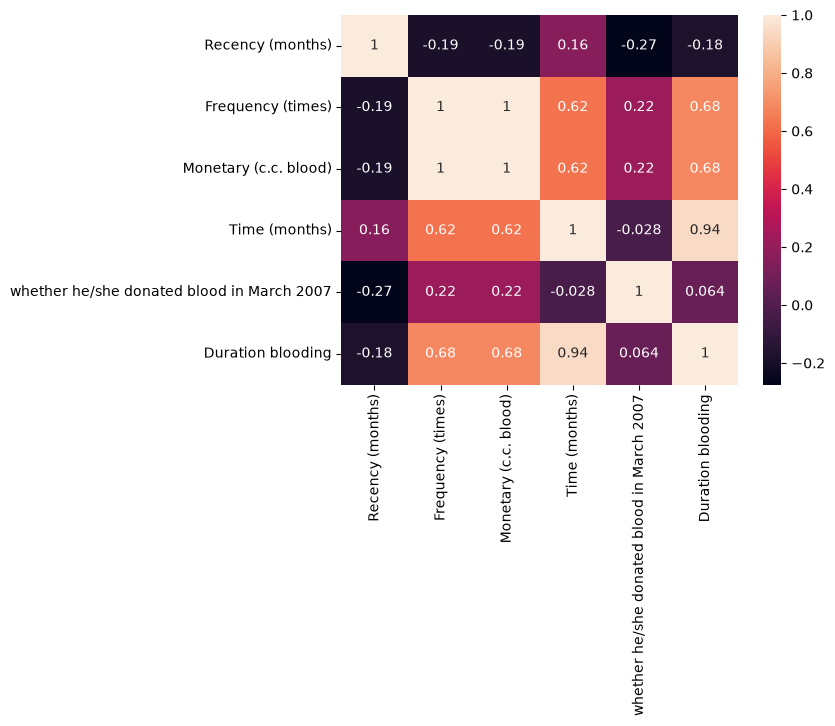

In [65]:
import seaborn as sns


corrolation = train.corr()
sns.heatmap(
    corrolation,
    annot=True
)

In [66]:
# Do preprocessing :)
# if you run this code line it shows that we do not have Nan values so we do not need to fill them
# =>  print(newTrain.isna().sum())

# Workflow 1- Remove outliers based on the Monetary 2- Polynominal 3- StandardScaler
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

def removeOuyliers(trainInp: pd.DataFrame):
    monetaryQuantileFirst = trainInp["Monetary (c.c. blood)"].quantile(0.25)
    monetaryQuantileThird = trainInp["Monetary (c.c. blood)"].quantile(0.75)
    monetaryIQR = monetaryQuantileThird - monetaryQuantileFirst

    upperBound = monetaryQuantileThird + 1.5*monetaryIQR
    lowerBound = monetaryQuantileFirst - 1.5*monetaryIQR

    trainInp = trainInp[(trainInp["Monetary (c.c. blood)"] > lowerBound) & 
        (trainInp["Monetary (c.c. blood)"] < upperBound)]

    return trainInp

# Remove the outliers.
# train = removeOuyliers(train)

# Scaling
logesticPipeLine = Pipeline([
    ("poly", PolynomialFeatures(degree=8)),
    ("scaler", StandardScaler()),
])

trainNew, validationCv = train_test_split(train, random_state=42, test_size=0.3)

train_x = train.drop(columns=["whether he/she donated blood in March 2007"])
train_y = train["whether he/she donated blood in March 2007"]

trainNew_x = trainNew.drop(columns=["whether he/she donated blood in March 2007"])
trainNew_y = trainNew["whether he/she donated blood in March 2007"]

validation_x = validationCv.drop(columns=["whether he/she donated blood in March 2007"])
validation_y = validationCv["whether he/she donated blood in March 2007"]

test_x = test

train_x = logesticPipeLine.fit_transform(train_x)
test_x = logesticPipeLine.transform(test_x)
validation_x = logesticPipeLine.transform(validation_x)

print(train_x)

[[ 0.          0.80057229 -0.60045016 ... -0.08932307 -0.11055156
  -0.12717118]
 [ 0.          0.18928893  0.79180809 ... -0.22737443 -0.22107983
  -0.21544726]
 [ 0.          0.43380227 -0.2523856  ... -0.22764081 -0.22126941
  -0.21558184]
 ...
 [ 0.         -0.66650777 -0.60045016 ... -0.22764084 -0.22126939
  -0.21558181]
 [ 0.         -0.66650777 -0.77448244 ... -0.22764095 -0.22126946
  -0.21558186]
 [ 0.         -0.66650777 -0.60045016 ... -0.22764095 -0.22126946
  -0.21558186]]


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مدل‌سازی
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    حال که داده را پاکسازی کرده و احتمالا ویژگی‌هایی را به آن افزوده یا از آن حذف کرده‌اید، وقت آن است که مدلی آموزش دهید که بتواند متغیر هدف این مسئله را پیش‌بینی کند.
</font>
</p>


<h3 align=center style="direction: rtl; line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#cb1111">
    شما تنها و تنها می‌توانید از <code>LogisticRegression</code> و کتابخانه <code>scikit-learn</code> استفاده کنید. در صورت استفاده از کتابخانه یا مدل دیگری، هیچ امتیازی به شما تعلق نخواهد گرفت.
</font>
</h3>


In [67]:
# Model Target column :)
model = LogisticRegression(max_iter=200)

model.fit(train_x, train_y)
y_prediction = model.predict(validation_x)

/home/amirreza-s-nasiri/Documents/Programming/Artificial-Inteligance-Boot-Camp/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
معیار ارزیابی
</font>
</h3>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    برای ارزیابی عملکرد مدل خود می‌توانید از معیار <code>f1_score</code> که در حالت <i>macro</i> میانگین‌گیری می‌کند، استفاده کنید. برای استفاده در کد می‌توانید به قطعه کد زیر توجه کنید.
    <br>
</font>
</p>

```
    from sklearn.metrics import f1_score
    print(f1_score(y_true, y_pred, average='macro'))
```


<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    برای کسب اطلاعات بیشتر در مورد <code>macro f1_score</code> می توانید <a href="https://towardsdatascience.com/micro-macro-weighted-averages-of-f1-score-clearly-explained-b603420b292f#:~:text=The%20macro%2Daveraged%20F1%20score,regardless%20of%20their%20support%20values.&text=The%20value%20of%200.58%20we,score%20in%20our%20classification%20report.">این لینک</a> را مطالعه کنید.
</font>
</p>



In [68]:
# Evaluete model :)
from sklearn.metrics import f1_score
score = f1_score(validation_y, y_prediction, average="macro")
print(f"Score : {score}")

Score : 0.6570458404074703


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
 پیش‌بینی برای داده تست و خروجی
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    پس از مهندسی ویژگی و مدلسازی، الگوریتمی دارید که می‌تواند شما را از متغیرهای وابسته به متغیر هدف برساند.
    <br>
    از این مدل برای پیش‌بینی نمونه‌های موجود در داده تست استفاده کنید و نتایج را در قالب جدول (<code>dataframe</code>) زیر آماده کنید.
</font>
</p>

<div dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    
|ستون|توضیحات|
|:------:|:---:|
|prediction|آیا شهروند در مارس ۲۰۰۷ خون اهدا کرده است یا خیر|
    
</font>
</div>



<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    اسم دیتافریم باید <i>submission</i> باشد؛ در غیر این صورت، سامانه داوری نمی‌تواند تلاش‌ شما را ارزیابی کند.
    <br>
    این دیتافریم تنها شامل ۱ ستون با اسم <i>prediction</i> است و ۷۵ سطر دارد.
    <br>
    به ازای هر سطر موجود در دیتافریم <i>test</i> شما باید یک مقدار پیشبینی شده داشته باشید.
    <br>
    جدول زیر، ۵ سطر ابتدایی دیتافریم <code>submission</code> را نشان می‌دهد. البته در جواب شما، اعداد ستون <i>prediction</i> ممکن است متفاوت باشد.
</font>
</p>

<div style="text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    
||prediction|
|----|-----|
|0|0|
|1|0|
|2|0|
|3|1|
|4|0|

</font>
</div>



In [69]:
# Predict for test data :)
y_test_prediction = model.predict(test_x)
submission = pd.DataFrame(y_test_prediction)
submission.columns = ["prediction"]
print(submission)

    prediction
0            0
1            0
2            1
3            0
4            0
..         ...
70           0
71           0
72           0
73           0
74           0

[75 rows x 1 columns]


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
<b>سلول جواب‌ساز</b>
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    برای ساخته‌شدن فایل <code>result.zip</code> سلول زیر را اجرا کنید.
    <br>
    فایل <code>result.zip</code> را در کوئرا می‌بایست آپلود کنید و منتظر نتیجه داوری بمانید!
    <br>
    این فایل شامل <code>submission.csv</code> ، همین نوت‌بوک که در حال کد زدن داخل آن هستید و مدل ذخیره‌شده‌ی شماست.
</font>
</p>

In [70]:
import zipfile
import joblib

def compress(file_names):
    print("File Paths:")
    print(file_names)
    compression = zipfile.ZIP_DEFLATED
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            zf.write('./' + file_name, file_name, compress_type=compression)


joblib.dump(model, 'model')
submission.to_csv('submission.csv', index=False)

file_names = ['model', 'submission.csv', 'blood_donation.ipynb']
compress(file_names)

File Paths:
['model', 'submission.csv', 'blood_donation.ipynb']
